In [1]:
import gurobipy as gp
from gurobipy import GRB
import itertools
from collections.abc import Mapping, Sequence

from instance import Instance, Arc, Node

instance = Instance()
world = instance.world
scenarios = instance.scenarios
demands = instance.demands
paths_per_od = instance.paths_per_od
tau = instance.tau

model = gp.Model("asymmetric")
model.setParam("OutputFlag", 0)

V = world.ordered_nodes
A = world.ordered_arcs
I = world.I
N = world.individuals

n = world.total_population
t = world.network.travel_time
c = world.network.capacity
alpha = world.network.bpr_alpha
beta = world.network.bpr_beta

Set parameter Username
Set parameter LicenseID to value 2844113
Academic license - for non-commercial use only - expires 2027-07-13


In [2]:
T = {
    od: i
    for i, od in enumerate(demands.keys())
}

active_arcs = set(
    itertools.chain.from_iterable(
        itertools.chain.from_iterable(paths_per_od.values())
    )
)

profiles_per_od = {
    od: list(itertools.combinations_with_replacement(paths_per_od[od], n_k))
    for od, n_k in demands.items()
}

joint_action_profiles = list(itertools.product(*profiles_per_od.values()))

action_profile_flows: Sequence[Mapping[Arc, int]] = []
for joint_profile in joint_action_profiles:
    flow = {a: 0 for a in active_arcs}
    for od_profile in joint_profile:
        for path in od_profile:
            for a in path:
                flow[a] += 1
    action_profile_flows.append(flow)

for od, paths in paths_per_od.items():
    print(od)
    for i, path in enumerate(paths):
        print("\t", f"{i}:", path)
    print("\n")

# NOTE: vvv is underestimate b/c of left-facing edges
print(f"{len(active_arcs)=} ({len(active_arcs) / len(A) * 100:.2f}% of arcs)")
print(f"{len(profiles_per_od)=}")
print(f"{len(joint_action_profiles)=}")

((0, 0), (0, 3))
	 0: [((0, 0), (0, 1)), ((0, 1), (0, 2)), ((0, 2), (0, 3))]
	 1: [((0, 0), (1, 0)), ((1, 0), (1, 1)), ((1, 1), (0, 1)), ((0, 1), (0, 2)), ((0, 2), (0, 3))]
	 2: [((0, 0), (1, 0)), ((1, 0), (1, 1)), ((1, 1), (1, 2)), ((1, 2), (0, 2)), ((0, 2), (0, 3))]
	 3: [((0, 0), (0, 1)), ((0, 1), (0, 2)), ((0, 2), (1, 2)), ((1, 2), (1, 3)), ((1, 3), (0, 3))]


((2, 0), (2, 3))
	 0: [((2, 0), (2, 1)), ((2, 1), (2, 2)), ((2, 2), (2, 3))]
	 1: [((2, 0), (1, 0)), ((1, 0), (1, 1)), ((1, 1), (2, 1)), ((2, 1), (2, 2)), ((2, 2), (2, 3))]
	 2: [((2, 0), (1, 0)), ((1, 0), (1, 1)), ((1, 1), (1, 2)), ((1, 2), (2, 2)), ((2, 2), (2, 3))]
	 3: [((2, 0), (2, 1)), ((2, 1), (1, 1)), ((1, 1), (1, 2)), ((1, 2), (2, 2)), ((2, 2), (2, 3))]


len(active_arcs)=18 (52.94% of arcs)
len(profiles_per_od)=2
len(joint_action_profiles)=81796


In [3]:
# decision: sigma[omega, a] := \prob[a \mid \theta]
sigma = {}
for scenario_name in scenarios:
    for action_profile_idx in range(len(joint_action_profiles)):
        sigma[scenario_name, action_profile_idx] = model.addVar(
            vtype=GRB.CONTINUOUS, lb=0, ub=1,
            name=f"sigma_{scenario_name}_{action_profile_idx}"
        )

# constraint: \sum_{rho \in \mathcal{A}} sigma[\omega, rho] = 1
for scenario_name in scenarios:
    model.addConstr(
        gp.quicksum(
            sigma[scenario_name, action_profile_idx]
            for action_profile_idx in range(len(joint_action_profiles))
        ) == 1,
        name=f"sigma_{scenario_name}"
    )

In [4]:
def debug_model():
    model.optimize()
    assert model.Status == GRB.OPTIMAL, f"Optimization failed: {model.Status}"

    out = []
    out.append(f"{model.ObjVal=:.2f}")
    out.append(f"{model.Runtime=:.3f}s")

    for scenario_name in scenarios:
        out.append(f"\nState: {scenario_name}")

        for action_profile_idx, joint_profile in enumerate(joint_action_profiles):
            prob = sigma[scenario_name, action_profile_idx].X
            if prob > 1e-3:
                out.append(f"\tJoint Profile {action_profile_idx}: ({prob=:.3f})")
                for od, od_profile in zip(profiles_per_od.keys(), joint_profile):
                    path_flows = tuple(od_profile.count(path) for path in paths_per_od[od])
                    out.append(f"\t\t{od}: {path_flows}")

    return out, model.ObjVal

In [5]:
# objective: expected potential
expected_potential = gp.LinExpr()
for scenario_name, (_, mu) in scenarios.items():
    for action_profile_idx, flow in enumerate(action_profile_flows):
        potential = sum(
            sum(tau[scenario_name, a, k] for k in range(1, flow[a] + 1))
            for a in flow
        )
        expected_potential.addTerms(mu * potential, sigma[scenario_name, action_profile_idx])

model.setObjective(expected_potential, GRB.MINIMIZE)

selfish_out, _ = debug_model()
selfish_cost = 0
for scenario_name, (_, mu) in scenarios.items():
    for action_profile_idx, flow in enumerate(action_profile_flows):
        prob = sigma[scenario_name, action_profile_idx].X
        if prob > 1e-3:
            selfish_cost += mu * prob * sum(
                flow[a] * tau[scenario_name, a, flow[a]]
                for a in flow
            )

In [6]:
# objective: expected social cost
expected_social_cost = gp.LinExpr()
for scenario_name, (_, mu) in scenarios.items():
    for action_profile_idx, flow in enumerate(action_profile_flows):
        cost = sum(
            flow[a] * tau[scenario_name, a, flow[a]]
            for a in flow
        )
        expected_social_cost += mu * sigma[scenario_name, action_profile_idx] * cost

model.setObjective(expected_social_cost, GRB.MINIMIZE)

dictator_out, dictator_cost = debug_model()

In [7]:
# constraint: obedience (IC?)
for od, paths in paths_per_od.items():
    od_idx = T[od]
    expected_deviate_benefit = {
        (p0_idx, p1_idx): gp.LinExpr()
        for p0_idx in range(len(paths))
        for p1_idx in range(len(paths))
        if p0_idx != p1_idx
    }

    for scenario_name, (_, mu) in scenarios.items():
        for action_profile_idx, joint_profile in enumerate(joint_action_profiles):
            od_profile = joint_profile[od_idx]
            flow = action_profile_flows[action_profile_idx]
            sigma_var = sigma[scenario_name, action_profile_idx]

            for p0_idx, p0 in enumerate(paths):
                count = od_profile.count(p0) # num of agents of type OD routed to path p0 under the joint profile
                if count == 0:
                    continue

                cost_follow = sum(tau[scenario_name, a, flow[a]] for a in p0)
                p0_set = set(p0) # TODO: memoize this or something

                for p1_idx, p1 in enumerate(paths):
                    if p0_idx == p1_idx:
                        continue

                    cost_deviate = sum(
                        tau[scenario_name, a, flow[a] if a in p0_set else flow[a] + 1]
                        for a in p1
                    )

                    # faster than +=
                    expected_deviate_benefit[p0_idx, p1_idx].addTerms(
                        mu * count * (cost_follow - cost_deviate),
                        sigma_var
                    )

    for (p0_idx, p1_idx), expr in expected_deviate_benefit.items():
        model.addConstr(
            expr <= 0,
            name=f"obed_{od}_{p0_idx}_to_{p1_idx}"
        )

shaki_out, shaki_cost = debug_model()

In [8]:
print("Expected Social Costs:")
print(f"\tDICTATOR:\t{dictator_cost:.2f}")
print(f"\tSELFISH:\t{selfish_cost:.2f} ({selfish_cost / dictator_cost:.4f})")
print(f"\tSHAKI:\t\t{shaki_cost:.2f} ({shaki_cost / dictator_cost:.4f})")

Expected Social Costs:
	DICTATOR:	1162.77
	SELFISH:	1308.24 (1.1251)
	SHAKI:		1227.90 (1.0560)


In [9]:
print("DICTATOR:\n\n")
print("\n".join(dictator_out))
print("\n\n" + "="*25)
print("SELFISH:\n\n")
print("\n".join(selfish_out))
print("\n\n" + "="*25)
print("SHAKI:\n\n")
print("\n".join(shaki_out))

DICTATOR:


model.ObjVal=1162.77
model.Runtime=0.011s

State: nominal
	Joint Profile 40928: (prob=1.000)
		((0, 0), (0, 3)): (2, 2, 4, 2)
		((2, 0), (2, 3)): (6, 0, 4, 0)

State: accident
	Joint Profile 19180: (prob=1.000)
		((0, 0), (0, 3)): (4, 2, 3, 1)
		((2, 0), (2, 3)): (7, 0, 1, 2)


SELFISH:


model.ObjVal=714.97
model.Runtime=0.061s

State: nominal
	Joint Profile 12900: (prob=1.000)
		((0, 0), (0, 3)): (5, 1, 4, 0)
		((2, 0), (2, 3)): (6, 0, 4, 0)

State: accident
	Joint Profile 6587: (prob=1.000)
		((0, 0), (0, 3)): (6, 2, 2, 0)
		((2, 0), (2, 3)): (8, 0, 0, 2)


SHAKI:


model.ObjVal=1227.90
model.Runtime=0.134s

State: nominal
	Joint Profile 11756: (prob=0.314)
		((0, 0), (0, 3)): (5, 2, 3, 0)
		((2, 0), (2, 3)): (6, 0, 4, 0)
	Joint Profile 12900: (prob=0.521)
		((0, 0), (0, 3)): (5, 1, 4, 0)
		((2, 0), (2, 3)): (6, 0, 4, 0)
	Joint Profile 18906: (prob=0.165)
		((0, 0), (0, 3)): (4, 2, 4, 0)
		((2, 0), (2, 3)): (6, 0, 4, 0)

State: accident
	Joint Profile 6595: (prob=0.245)


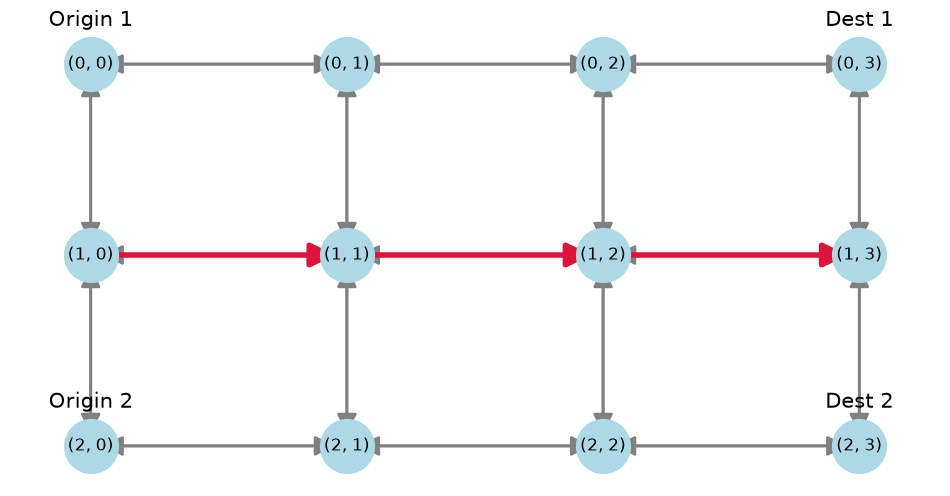

In [10]:
import networkx as nx
import matplotlib.pyplot as plt

G = world.network.graph
pos = {(r, c): (c, -r) for (r, c) in G.nodes}

plt.figure(figsize=(12, 6))

nx.draw_networkx_nodes(G, pos, node_color="lightblue", node_size=1500)
nx.draw_networkx_labels(G, pos, font_size=12)
nx.draw_networkx_edges(G, pos, G.edges(), edge_color="gray", arrows=True, width=2, arrowsize=30)
nx.draw_networkx_edges(G, pos, edgelist=instance.bottlenecks, edge_color="crimson", arrows=True, width=4, arrowsize=35)

for i, (origin, dest) in enumerate(instance.demands, 1):
    (x0, y0), (x1, y1) = pos[origin], pos[dest]
    plt.text(x0, y0 + .2, f"Origin {i}", fontsize=15, ha="center")
    plt.text(x1, y1 + .2, f"Dest {i}", fontsize=15, ha="center")

plt.axis(False)
plt.show()
